copy and pasted code from double pendulum simulation

In [1]:
import numpy as np
import jax.numpy as jnp
from jax import jit
import  jax
import matplotlib.pyplot as plt
import math
from matplotlib.animation import FuncAnimation
import itertools
from IPython.display import HTML
import pickle
import datetime;datetime.datetime.now()


#from jax.config import config
#config.update("jax_enable_x64", True)
#from jax import jit, grad
#import jax.numpy as jnp
#import jax

import matplotlib.animation as animation
from IPython.display import HTML
def resetMe(keepList=[]):
    ll=%who_ls
    keepList=keepList+['resetMe','np','plt','math','jax','jnp','jit','grad','HTML','animation','animateMe_singlependulum']
    for iiii in keepList:
        if iiii in ll:
            ll.remove(iiii)
    for iiii in ll:
        jjjj="^"+iiii+"$"
        %reset_selective -f {jjjj}
    ll=%who_ls
    plt.rcParams.update({"font.size": 14})
    return
resetMe()
import datetime;datetime.datetime.now()

datetime.datetime(2026, 5, 2, 18, 11, 30, 611967)

In [2]:
from dataclasses import dataclass
@dataclass
class DoublePendulumParams:
    """
    Define the parameters of the double pendulum system
    """
    L1: float   # length of the first pendulum
    L2: float   # length of the second pendulum

    m1: float = 1.0
    m2: float = 1.0
    g: float = 9.8 # restoring force

@dataclass
class DoublePendulumSimulation:
    """
    Define the simulation parameters for the double pendulum system
    """
    omega_0: np.ndarray # initial angular velocity (2,)
    theta_0: np.ndarray # initial angle (2,)

    dt: float = 0.01 # time step
    T: float = 20.0 # total time of the simulation


In [3]:
def force_two_pendulum(t1, t2, omega1, omega2, p):
  """"
  t1: angle of the upper pendulum
  t2: angle of the lower pendulum
  omega1: angular velocity of upper pendulum
  omega2: angular velocity of the upper pendulum
  p: a DoublePendulumParams object
  Returns:
  omega1_dot, omega2_dot : angular acceleration
  """
  f1=-p.L2/p.L1 *(p.m2/(p.m1+p.m2))*omega2**2*jnp.sin(t1-t2)-p.g/p.L1*jnp.sin(t1)
  f2=p.L1/p.L2 * omega1**2 * jnp.sin(t1-t2)-p.g/p.L2*jnp.sin(t2)
  alpha1=p.L2/p.L1*(p.m2/(p.m1+p.m2))*jnp.cos(t1-t2)
  alpha2=p.L1/p.L2*jnp.cos(t1-t2)
  den=(1-alpha1*alpha2)
  omega1_dot = (f1-alpha1*f2)/den
  omega2_dot = (-alpha2*f1+f2)/den
  return omega1_dot, omega2_dot

input size is 4 because thetas and omegas. output size is the same because the net is just gonna predict the next state of the double pendulum

In [16]:
from typing import NamedTuple

class Params(NamedTuple):
    W1: jnp.ndarray  # (d,4761)
    b1: jnp.ndarray  # (d)
    W2: jnp.ndarray  # (5,d)
    b2: jnp.ndarray  # 5

d = 64
input_size = 6
output_size = 6

key = jax.random.PRNGKey(12423)
p = Params(W1 = 0.1*jax.random.normal(key, (d, input_size)),
           b1 = jnp.zeros((d,)),
           W2 = 0.1*jax.random.normal(key, (output_size, d)),
           b2 = jnp.zeros(output_size))



def net(p,state_input):
  """
  Represent a regressor neural network for predicting double pendulum states.
  Arguments:
  p: a Params NamedTuple with W1, b1, W2, b2
  state_in: jnp.ndarray (4,) representing the kinematic state at time t
  Returns:
  state_out: jnp.ndarray (4,) representing the predicted state at time t + dt
  """
  y1 = p.W1@state_input + p.b1
  #normalize
  y1_normalize = jnp.tanh(y1)

  predicted_change = p.W2 @ y1_normalize + p.b2

  return predicted_change
  # return output

#initial state for testing
theta_upper, theta_lower, omega_upper, omega_lower = jnp.pi, jnp.pi, 0, 0
sin_theta_upper, cos_theta_upper, sin_theta_lower, cos_theta_lower, omega_upper, omega_lower = jnp.sin(jnp.pi), jnp.cos(jnp.pi), jnp.sin(jnp.pi), jnp.cos(jnp.pi), 0, 0
#both pendulum angles at theta and no starting velocity

state_input = jnp.array([sin_theta_upper, cos_theta_upper, sin_theta_lower, cos_theta_lower, omega_upper, omega_lower])

print(net(p, state_input))
print("it basically just gives random values")

[-0.11517756 -0.11125267 -0.19076675 -0.07089836  0.13021785  0.19249102]
it basically just gives random values


now we need to write a mean squared error loss function in order to train

In [17]:
#we have to calculate mse of difference of states in order to get values that arent like 99% similar
def mean_squared_error(p, in_state, out_state):
  predicted_change = net(p, in_state)

  actual_change = out_state - in_state

  squared_errors = (predicted_change - actual_change)**2
  
  mse = jnp.mean(squared_errors)
  return mse


#use our double pendulum function to calculate the next step of the pendulum trajectory.
dpp = DoublePendulumParams(m1=1,m2=1,L1=1,L2=1,g=9.8)
dps = DoublePendulumSimulation(T=15,dt=0.01,theta_0=np.array([1,1+0.11]),omega_0=np.array([0.0,0.0]))

def calculate_next_step_dp(initial_state, dt):
  """
  calculates the next step in a double pendulums trajectory
  arguments:
  initial_state: parameters of the intial state of the double pendulum ([theta_upper, theta_lower, omega_upper, omega_lower])
  dt: timestep
  returns:
  state_out: thetas and omegas after the timestep ([theta_upper, theta_lower, omega_upper, omega_lower])
  """
  #params for force function
  dpp = DoublePendulumParams(m1=1,m2=1,L1=1,L2=1,g=9.8)

  theta_upper = initial_state[0]
  theta_lower = initial_state[1]
  omega_upper = initial_state[2]
  omega_lower = initial_state[3]
  t=0


  alpha_initial_upper, alpha_initial_lower = force_two_pendulum(theta_upper,theta_lower,omega_upper, omega_lower,dpp)

  #upper
  theta_midpoint_upper = theta_upper + omega_upper*(dt/2)
  omega_midpoint_upper = omega_upper + (alpha_initial_upper)*(dt/2)

  #lower
  theta_midpoint_lower = theta_lower + omega_lower*(dt/2)
  omega_midpoint_lower = omega_lower + (alpha_initial_lower)*(dt/2)

  t_midpoint = t + (dt / 2)

  #alpha_midpoint = -p.A*omega_midpoint-p.B*np.sin(theta_midpoint)+p.C*np.sin(p.omega_drive*t_midpoint)
  alpha_midpoint_upper, alpha_midpoint_lower = force_two_pendulum(theta_midpoint_upper, theta_midpoint_lower,omega_midpoint_upper, omega_midpoint_lower,dpp)


  theta_upper += omega_midpoint_upper*dt
  theta_lower += omega_midpoint_lower*dt
  omega_upper += alpha_midpoint_upper*dt
  omega_lower += alpha_midpoint_lower*dt


  #state_out = jnp.array([theta_upper, theta_lower, omega_upper, omega_lower])
  #map thetas to sins and cosines to make sure that values are continuous
  state_out = jnp.array([theta_upper, theta_lower, omega_upper, omega_lower])
  

  return state_out





Now, similarly to the previous machine learning activity, we need to take the gradient of the error function and descend down

In [18]:
#we can almost train. first we need to create a dataset from our double pendulum simulation

#we need to generate trajectories of 1000 steps for 1000 initial starting positions

from functools import partial

def generate_initial_states(num_trajectories):
  thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(num_trajectories, 2))

  omegas = np.random.uniform(low=-5.0, high=5.0, size=(num_trajectories, 2))

  initial_states = np.concatenate((thetas, omegas), axis=1)


  return initial_states

#now that we have initial_states we have to calculate trajectories of 1000 steps each

vectorized_calc_next_step = jax.vmap(calculate_next_step_dp, in_axes=(0, None))

def scan_step_fn(dt, current_state, _):
    next_state = calculate_next_step_dp(current_state, dt)
    return next_state, (current_state, next_state)

def generate_single_trajectory(initial_state, num_steps, dt):
  bound_step_fn = partial(scan_step_fn, dt)
  final_state, (inputs, outputs) = jax.lax.scan(
     bound_step_fn,
     initial_state,
     jnp.arange(num_steps)
  )
  return inputs, outputs
  
def to_6d_state(states):
   theta_upper = states[:,0]
   theta_lower = states[:,1]
   omega_upper = states[:,2]
   omega_lower = states[:,3]
   return jnp.stack([
      jnp.sin(theta_upper), jnp.cos(theta_upper), jnp.sin(theta_lower), jnp.cos(theta_lower),
      omega_upper, omega_lower
   ], axis=1)


def populate_training_data(initial_states, num_steps, dt):
  # We can use partial here too if we want to bind num_steps and dt to the vmap
    bound_trajectory_fn = partial(generate_single_trajectory, num_steps=num_steps, dt=dt)
    vectorized_trajectory_gen = jax.vmap(bound_trajectory_fn)
    
    inputs_batch, outputs_batch = vectorized_trajectory_gen(initial_states)
    
    training_outputs = outputs_batch.reshape(-1,4)
    training_inputs = inputs_batch.reshape(-1, 4)

    #we wanna predict change in values because the difference is gonna be too small if we look at the state as a whole
    training_inputs = to_6d_state(training_inputs)
    training_outputs = to_6d_state(training_outputs)
    
    
    return training_inputs, training_outputs

initial_states = generate_initial_states(1000)
training_inputs, training_outputs = populate_training_data(initial_states, 1000, 0.01)


In [19]:
#now that we have our training set and our loss function we can descend

#take gradient of mse function
mse_grad = jit(jax.grad(jit(mean_squared_error)))

#we are gonna train with batch size of 1 like last time
def train(params, training_inputs, training_outputs, steps=100000, learning_rate=1e-5):
  p = params
  mse_history = []
  step_list = []
  num_samples = len(training_inputs)

  for i in range(steps):
    #pick a random index
    random_index = np.random.randint(0, num_samples)
    #random_indices = np.random.randint(0, num_samples, size=batch_size)
    #input_batch = training_inputs[random_indices]
    #output_batch = training_outputs[random_indices]

    input = training_inputs[random_index]
    output = training_outputs[random_index]
    gradient = mse_grad(p, input, output)

    new_W1 = p.W1 - gradient.W1 * learning_rate
    new_W2 = p.W2 - gradient.W2 * learning_rate
    new_b1 = p.b1 - gradient.b1 * learning_rate
    new_b2 = p.b2 - gradient.b2 * learning_rate
    p = p._replace(W1=new_W1, W2=new_W2, b1=new_b1, b2=new_b2)

    step_list.append(i)
    mse_history.append(mean_squared_error(p, input, output))

    if (i % 1000 == 0):
      print(mean_squared_error(p, input, output))

  return p, mse_history, step_list






In [20]:

key = jax.random.PRNGKey(12423)
p = Params(W1 = 0.1*jax.random.normal(key, (d, input_size)),
           b1 = jnp.zeros((d,)),
           W2 = 0.1*jax.random.normal(key, (output_size, d)),
           b2 = jnp.zeros(output_size))


trained_params, mse_history, step_list = train(p, training_inputs, training_outputs)

0.09880924
0.04817927
0.07832237
0.061815705
0.3287641
0.14135365
0.21538559
0.007844768
0.023489496
0.023025312
0.04891145
0.06559605
0.015802652
0.022283552
0.03345054
0.092561804
0.00951007
0.010438679
0.020571578
0.14303286
0.003009211
0.021953974
0.019629247
0.015612358
0.01708398
0.013228027
0.033899657
0.020396244
0.009413536
0.018839989
0.01966549
0.042819023
0.021301871
0.01156988
0.013089299
0.0076784417
0.007059797
0.021110099
0.037980255
0.040251628
0.018013522
0.034355216
0.010867612
0.05676159
0.025430819
0.03192536
0.014044828
0.022892058
0.007797218
0.019194212
0.02293784
0.066435695
0.00679016
0.059583392
0.024012223
0.05724941
0.01658281
0.08584364
0.031381954
0.011766086
0.0014774211
0.049285233
0.03854625
0.024317948
0.020261759
0.021548979
0.011119
0.008396258
0.0073956056
0.009419101
0.007720393
0.0063003674
0.015225768
0.0045133946
0.026275007
0.03253396
0.015537503
0.022180242
0.03574782
0.015302891
0.014516454
0.023585213
0.010254937
0.008338843
0.01391603
0.00

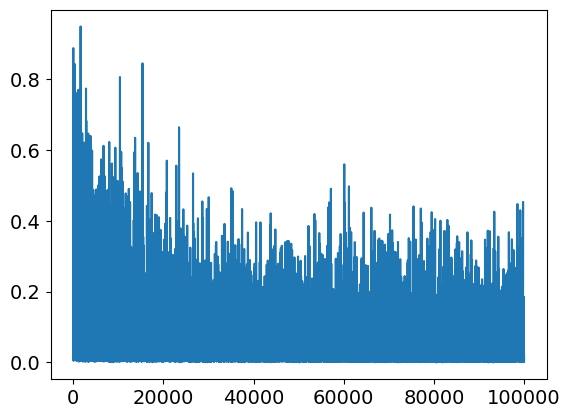

In [21]:
#looks ok but theres a lot of noise at the bottom and its converging really fast so maybe something is wrong
plt.plot(step_list, mse_history);



this is fine but our function reaches suitable w and b values way too quickly and it ends up being weird and noisy at the end

In [22]:

#initial state for testing
theta_upper, theta_lower, omega_upper, omega_lower = 0.1, 0.1, 0, 0
#both pendulum angles at theta and no starting velocity
initial_state = jnp.array([jnp.sin(theta_upper),jnp.cos(theta_upper), jnp.sin(theta_lower), jnp.cos(theta_lower), omega_upper, omega_lower])
print("heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0:")

predicted_change = net(trained_params, initial_state)
predicted_next_state = initial_state + predicted_change
print(predicted_next_state)

print('')
print("and heres the actual (numerical) calculation for the next position")
print(calculate_next_step_dp(initial_state, 0.01)) 
print()


heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0:
[ 0.2022776   1.105068    0.2477032   1.0550863  -0.09555184 -0.1432766 ]

and heres the actual (numerical) calculation for the next position
[0.10095496 1.0044658  0.12383596 0.8975158 ]



In [23]:
def batch_mse(params, input_batch, output_batch):
  losses = jax.vmap(mean_squared_error, in_axes=(None, 0, 0))(params, input_batch, output_batch)
  return jnp.mean(losses)

batch_mse_grad = jit(jax.grad(jit(batch_mse)))

def train_with_batches(params, training_inputs, training_outputs, batch_size=32, steps=100000, learning_rate=1e-5):
  p = params
  mse_history = []
  step_list = []
  num_samples = len(training_inputs)

  for i in range(steps):
    #pick a random index
    random_indices = np.random.randint(0, num_samples, size=batch_size)
    input_batch = training_inputs[random_indices]
    output_batch = training_outputs[random_indices]

    gradient = batch_mse_grad(p, input_batch, output_batch)

    new_W1 = p.W1 - gradient.W1 * learning_rate
    new_W2 = p.W2 - gradient.W2 * learning_rate
    new_b1 = p.b1 - gradient.b1 * learning_rate
    new_b2 = p.b2 - gradient.b2 * learning_rate
    p = p._replace(W1=new_W1, W2=new_W2, b1=new_b1, b2=new_b2)

    if (i % 2000 == 0):
      step_list.append(i)
      mse_history.append(batch_mse(p, input_batch, output_batch))
      print(batch_mse(p, input_batch, output_batch))
      
  return p, mse_history, step_list

In [24]:

key = jax.random.PRNGKey(12423)
p = Params(W1 = 0.1*jax.random.normal(key, (d, input_size)),
           b1 = jnp.zeros((d,)),
           W2 = 0.1*jax.random.normal(key, (output_size, d)),
           b2 = jnp.zeros(output_size))


trained_params, mse_history, step_list = train_with_batches(p, training_inputs, training_outputs, steps=500000, batch_size = 4096, learning_rate=1e-3)


0.095673315
0.023904558
0.019785224
0.017876765
0.016614359
0.016078655
0.0148311015
0.015023669
0.013699278
0.013379771
0.013764004
0.013242376
0.01399225
0.013104284
0.013183138
0.013307312
0.013566709
0.013685632
0.013479486
0.014174846


KeyboardInterrupt: 

heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0:
[ 0.10244419  0.11006376  0.14786977  0.06008202 -0.09555184 -0.1432766 ]

and heres the actual (numerical) calculation for the next position
[0.10095496 1.0044658  0.12383596 0.8975158 ]



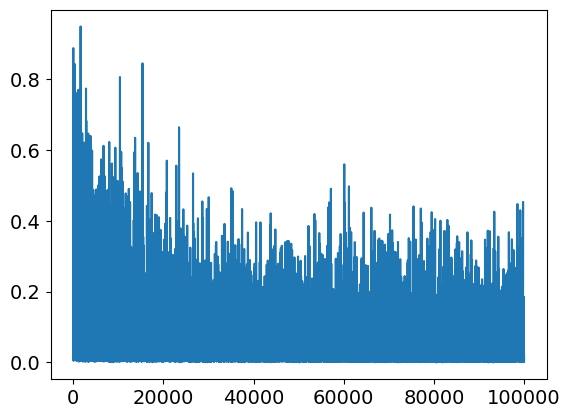

In [25]:
plt.plot(step_list, mse_history);



#initial state for testing
theta_upper, theta_lower, omega_upper, omega_lower = 0.1, 0.1, 0, 0
#both pendulum angles at theta and no starting velocity
initial_state = jnp.array([jnp.sin(theta_upper),jnp.cos(theta_upper), jnp.sin(theta_lower), jnp.cos(theta_lower), omega_upper, omega_lower])

print("heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0:")
print(net(trained_params, initial_state))
print('')
print("and heres the actual (numerical) calculation for the next position")
print(calculate_next_step_dp(initial_state, 0.01))
print()



In [ ]:
def adam_training(params, training_inputs, training_outputs, batch_size=32, steps=100000, learning_rate=1e-3, b1=0.9, b2=0.999, eps=1e-8):
    p = params
    mse_history = []
    step_list = []
    num_samples = len(training_inputs)

    m_W1, v_W1 = jnp.zeros_like(p.W1), jnp.zeros_like(p.W1)
    m_b1, v_b1 = jnp.zeros_like(p.b1), jnp.zeros_like(p.b1)
    m_W2, v_W2 = jnp.zeros_like(p.W2), jnp.zeros_like(p.W2)
    m_b2, v_b2 = jnp.zeros_like(p.b2), jnp.zeros_like(p.b2)
  
    def update_param(param, grad, m, v, t):
        m= b1*m+(1-b1)*grad
        v=b2*v+(1-b2)*(grad**2)
        m_hat = m/(1-b1**t)
        v_hat=v/(1-b2**t)
        new_param = param - learning_rate * m_hat / (jnp.sqrt(v_hat) + eps)
        return new_param, m, v

    for i in range(1, steps + 1):
        #pick a random index
        random_indices = np.random.randint(0, num_samples, size=batch_size)
        input_batch = training_inputs[random_indices]
        output_batch = training_outputs[random_indices]

        gradient = batch_mse_grad(p, input_batch, output_batch)

        new_W1, m_W1, v_W1 = update_param(p.W1, gradient.W1, m_W1, v_W1, i)
        new_b1, m_b1, v_b1 = update_param(p.b1, gradient.b1, m_b1, v_b1, i)
        new_W2, m_W2, v_W2 = update_param(p.W2, gradient.W2, m_W2, v_W2, i)
        new_b2, m_b2, v_b2 = update_param(p.b2, gradient.b2, m_b2, v_b2, i)

        p = p._replace(W1=new_W1, W2=new_W2, b1=new_b1, b2=new_b2)
#
        if (i % 2000 == 0):
            step_list.append(i)
            mse_history.append(batch_mse(p, input_batch, output_batch)) # py
            print(batch_mse(p, input_batch, output_batch))
        
    return p, mse_history, step_list

In [40]:

key = jax.random.PRNGKey(12423)
p = Params(W1 = 0.1*jax.random.normal(key, (d, input_size)),
           b1 = jnp.zeros((d,)),
           W2 = 0.1*jax.random.normal(key, (output_size, d)),
           b2 = jnp.zeros(output_size))


trained_params, mse_history, step_list = adam_training(p, training_inputs, training_outputs)


0.013088684
0.0051211445
0.004435548
0.004348985
0.0023394495
0.002752465
0.0010618996
0.0031570063
0.00338239
0.002014106
0.0014941978
0.0014611508
0.00225453
0.0022435584
0.0008808498
0.0014318808
0.0022465398
0.0018448924
0.001908966
0.00090853893
0.00053063955
0.00085669593
0.0011356923
0.0012816475
0.0016093148
0.0010533166
0.0012960233
0.0017089964
0.0009644772
0.0010007244
0.00136083
0.0006495232
0.00085873913
0.0012358753
0.00090082333
0.0008118387
0.00064501865
0.0006148028
0.00049132155
0.00042009744
0.00079211465
0.0010087674
0.00090456125
0.0011952625
0.0006502224
0.00094835705
0.000880267
0.00075369445
0.0012741907
0.0011592377


In [46]:
theta_upper, theta_lower, omega_upper, omega_lower = 0.1, 0.1, 0.0, 0.0


net_input_state = jnp.array([jnp.sin(theta_upper), jnp.cos(theta_upper), 
                             jnp.sin(theta_lower), jnp.cos(theta_lower), 
                             omega_upper, omega_lower])

predicted_change = net(trained_params, net_input_state)
net_predicted_next_state = net_input_state + predicted_change

numerical_input_state = jnp.array([theta_upper, theta_lower, omega_upper, omega_lower])
numerical_output = calculate_next_step_dp(numerical_input_state, 0.01)

# Convert the numerical solver's 4-element output back explicitly into the 6-element representation for comparison
numerical_6d_output = jnp.array([
    jnp.sin(numerical_output[0]), jnp.cos(numerical_output[0]),
    jnp.sin(numerical_output[1]), jnp.cos(numerical_output[1]),
    numerical_output[2], numerical_output[3]
])

print("heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0 (6D):")
print(net_predicted_next_state)

print('')
print("and heres the numerical calculation for the next position formatted to 6D:")
print(numerical_6d_output)
print()

heres the neural nets prediction for theta_1 = 0.1, theta_2 = 0.1, and omegas = 0 (6D):
[ 0.09806933  0.9896185   0.09989408  0.99789023 -0.03315083  0.0043607 ]

and heres the numerical calculation for the next position formatted to 6D:
[ 0.09978474  0.99500906  0.09983342  0.9950042  -0.00978368  0.        ]

